In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

In [5]:
col_names=['pregnant','glucose','bp','skin','insulin','bmi','pedigree','age','outcome']
data=pd.read_csv('/content/diabetes.csv', header=0) # Read with the first row as header
data.columns = col_names # Assign the desired column names

print(data.shape)
data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
outcome,0


In [7]:
feature_cols=['pregnant','insulin','bmi','age','glucose','bp','pedigree']
x=data[feature_cols]
y=data.outcome

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)
display(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(614, 7)

(614,)

(154, 7)

(154,)

In [9]:
model=LogisticRegression(solver='lbfgs',max_iter=1000)

In [10]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [11]:
conf_mat=metrics.confusion_matrix(y_test,y_pred)
print('Confusion Matrix: ',conf_mat)
Accuracy_score=metrics.accuracy_score(y_test,y_pred)
print('Accuracy Score: ',Accuracy_score)
print('Accuracy in percentage :',int(Accuracy_score*100),'%')
Precision_score = metrics.precision_score(y_test, y_pred)
print('Precision Score:', Precision_score)

Recall_score = metrics.recall_score(y_test, y_pred)
print('Recall Score:', Recall_score)

F1_score = metrics.f1_score(y_test, y_pred)
print('F1-Score:', F1_score)

Confusion Matrix:  [[88 12]
 [19 35]]
Accuracy Score:  0.7987012987012987
Accuracy in percentage : 79 %
Precision Score: 0.7446808510638298
Recall Score: 0.6481481481481481
F1-Score: 0.693069306930693


<Axes: xlabel='Predicted outcome', ylabel='Actual outcome'>

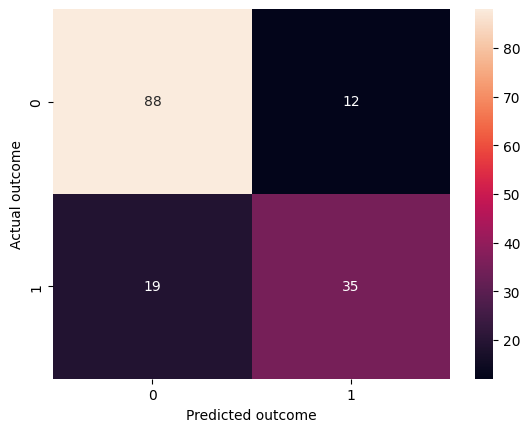

In [12]:
conf_mat=pd.crosstab(y_test,y_pred,rownames=['Actual outcome'],colnames=['Predicted outcome'])
sn.heatmap(conf_mat,annot=True)